# Proyecto 1: Modelo Causal Decoder-Only desde Cero

## Objetivos

1. Implementar desde cero la atención causal multi-head con máscara triangular inferior.
2. Ensamblar un bloque decoder con Pre-LayerNorm (estilo GPT-2).
3. Entrenar el modelo sobre el corpus IMDB y evaluar con perplexidad.
4. Visualizar los pesos de atención aprendidos por el modelo.
5. Comparar la generación propia frente a `distilgpt2` preentrenado.

## Celda de verificación personal

In [1]:
# ─── CELDA DE VERIFICACIÓN PERSONAL ───────────────────────────────
STUDENT_NAME   = "Baca Sandoval Luis Jhonatan"
EXECUTION_DATE = "2026-06-11"
BASE_NOTEBOOK  = "Cuaderno12-CC0C2.ipynb"
MODEL_NAME     = "CausalDecoderLM (desde cero) + distilgpt2 (referencia)"
SEED           = 42
PROMPTS        = ['The movie was', 'This film is about', 'The acting in this']
VARIANT        = "Reduccion de N_LAYERS 4->2 y comparacion de politicas de decoding"

print("Estudiante:", STUDENT_NAME)
print("Fecha:", EXECUTION_DATE)
print("Cuaderno base:", BASE_NOTEBOOK)
print("Modelo:", MODEL_NAME)
print("Semilla:", SEED)
print("Variante:", VARIANT)

Estudiante: Baca Sandoval Luis Jhonatan
Fecha: 2026-06-11
Cuaderno base: Cuaderno12-CC0C2.ipynb
Modelo: CausalDecoderLM (desde cero) + distilgpt2 (referencia)
Semilla: 42
Variante: Reduccion de N_LAYERS 4->2 y comparacion de politicas de decoding


In [2]:
import math
import random
from collections import Counter
from typing import List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed

set_seed(42)
random.seed(42)
torch.manual_seed(42)

import warnings
warnings.filterwarnings('ignore')

print('Dependencias cargadas correctamente.')

Dependencias cargadas correctamente.


## 1. Marco teórico: La factorización autoregresiva

Un modelo de lenguaje causal estima la densidad conjunta de una secuencia de tokens $x_{1:T}$
mediante la **regla de la cadena** de probabilidad:

$$
p_\theta(x_{1:T}) = \prod_{t=1}^{T} p_\theta(x_t \mid x_{<t})
$$

donde $x_{<t} = (x_1, \dots, x_{t-1})$ es el contexto izquierdo.

### ¿Cómo lo implementa un Transformer causal?

El Transformer usa atención multi-head, pero restringe qué posiciones pueden ser atendidas:
el token en la posición $t$ **solo puede ver** posiciones $j \le t$. Esto se logra con
una **máscara causal** triangular inferior:

$$
M_{ij} = \begin{cases} 0 & \text{si } j \le i \\ -\infty & \text{si } j > i \end{cases}
$$

Tras el softmax, los $-\infty$ se convierten en $0$, bloqueando efectivamente la atención futura.

### Flujo del modelo

$$
\text{tokens} \xrightarrow{\text{emb}} \mathbf{X}^{(0)}
\xrightarrow{\text{PE}} \mathbf{H}^{(0)}
\xrightarrow{L \text{ bloques}} \mathbf{H}^{(L)}
\xrightarrow{\text{LN} + W_{\text{head}}} \mathbf{Z} \in \mathbb{R}^{T \times |\mathcal{V}|}
$$

In [3]:
# ─── Hiperparámetros del proyecto ──────────────────────────────────────────────
SEQ_LEN    = 64      # longitud de cada bloque de entrenamiento (en tokens)
BATCH_SIZE = 32      # tamaño del lote
D_MODEL    = 256     # dimensión del embedding / modelo
N_HEADS    = 4       # número de cabezas de atención (d_head = D_MODEL / N_HEADS = 64)
N_LAYERS   = 4       # número de bloques decoder
D_FF       = 1024    # dimensión interna del FFN (4 × D_MODEL, convención estándar)
DROPOUT    = 0.1     # tasa de dropout
EPOCHS     = 5       # épocas de entrenamiento
LR         = 3e-4    # tasa de aprendizaje inicial

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

DEVICE = get_device()
print('Dispositivo:', DEVICE)

Dispositivo: cuda


## 2. Corpus y tokenización

Reutilizamos el pipeline de Cuaderno12-CC0C2 (Secciones 3–8): tokenizador BPE de `distilgpt2`,
corpus IMDB (solo texto, ignoramos etiquetas) y dataset causal con pares $(x, y)$ donde $y_t = x_{t+1}$.

In [4]:
# ─── REUTILIZADO DE: Cuaderno12-CC0C2, Sección 3 ─────────────────────────────
# Tokenizador de subpalabras (BPE). Formalmente: τ: Σ* → V*
MODEL_TOKENIZER = 'distilgpt2'

tokenizer = AutoTokenizer.from_pretrained(MODEL_TOKENIZER)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

VOCAB_SIZE = tokenizer.vocab_size
print('Tamaño del vocabulario:', VOCAB_SIZE)
print('Token EOS:', tokenizer.eos_token, '| id:', tokenizer.eos_token_id)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tamaño del vocabulario: 50257
Token EOS: <|endoftext|> | id: 50256


In [5]:
# ─── REUTILIZADO DE: Cuaderno12-CC0C2, Sección 4 ─────────────────────────────
# Corpus IMDB: solo texto, ignoramos etiquetas de sentimiento
dataset = load_dataset('imdb')

train_texts = dataset['train']['text'][:2000]
valid_texts = dataset['test']['text'][:400]

print('Ejemplos train:', len(train_texts))
print('Ejemplos valid:', len(valid_texts))
print('\nFragmento de ejemplo:')
print(train_texts[0][:300], '...')

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Ejemplos train: 2000
Ejemplos valid: 400

Fragmento de ejemplo:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h ...


In [7]:
# ─── REUTILIZADO DE: Cuaderno12-CC0C2, Sección 5 ─────────────────────────────
# Tokeniza y concatena documentos con EOS como separador:
#   x̃ = x^(1) ⊕ <eos> ⊕ x^(2) ⊕ ...
def tokenize_corpus(texts: List[str]) -> List[int]:
    ids = []
    for txt in texts:
        toks = tokenizer.encode(txt, add_special_tokens=False)
        ids.extend(toks + [tokenizer.eos_token_id])
    return ids

train_ids = tokenize_corpus(train_texts)
valid_ids = tokenize_corpus(valid_texts)

print(f'Total tokens train: {len(train_ids):,}')
print(f'Total tokens valid: {len(valid_ids):,}')

Total tokens train: 582,936
Total tokens valid: 118,095


In [8]:
# ─── REUTILIZADO DE: Cuaderno12-CC0C2, Sección 8 ─────────────────────────────
# Dataset causal: pares (x, y) donde y_t = x_{t+1}
# Implementa la factorización: p(x_{1:T}) = ∏_t p(x_t | x_{<t})
class CausalLMDataset(Dataset):
    def __init__(self, token_ids: List[int], seq_len: int = 64, stride: int = 64):
        self.examples = []
        for start in range(0, len(token_ids) - seq_len - 1, stride):
            x = token_ids[start : start + seq_len]
            y = token_ids[start + 1 : start + seq_len + 1]
            self.examples.append((
                torch.tensor(x, dtype=torch.long),
                torch.tensor(y, dtype=torch.long)
            ))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]

train_ds = CausalLMDataset(train_ids, seq_len=SEQ_LEN, stride=SEQ_LEN)
valid_ds = CausalLMDataset(valid_ids, seq_len=SEQ_LEN, stride=SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE)

x_b, y_b = next(iter(train_loader))
print(f'Batches train: {len(train_loader)}  |  valid: {len(valid_loader)}')
print(f'Forma lote x: {x_b.shape}  |  y: {y_b.shape}')

Batches train: 285  |  valid: 58
Forma lote x: torch.Size([32, 64])  |  y: torch.Size([32, 64])


## 3. Arquitectura desde cero

### 3.1 Codificación posicional sinusoidal

La autoatención es invariante al orden (es una operación sobre conjuntos). Para dotar al
modelo de información posicional, sumamos una señal determinista:

$$
\text{PE}_{pos,2i} = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \quad
\text{PE}_{pos,2i+1} = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)
$$

La entrada al primer bloque es $h_t^{(0)} = E[x_t] + \text{PE}_t$.

In [9]:
# ─── REUTILIZADO DE: Cuaderno12-CC0C2, Sección 10 ────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 2048):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)          # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

### 3.2 Atención causal multi-head (desde cero)

La atención de producto punto escalado se define como:

$$
\text{Attn}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

donde $d_k = d_{\text{model}} / H$ es la dimensión por head ($H$ = número de heads).

En la versión **multi-head** cada head aprende proyecciones independientes:

$$
\text{MHA}(X) = \text{Concat}(\text{head}_1, \dots, \text{head}_H)\, W^O, \quad
\text{head}_i = \text{Attn}(XW^Q_i,\; XW^K_i,\; XW^V_i)
$$

La **máscara causal** garantiza que $x_t$ solo atienda a posiciones $j \le t$:

$$
\tilde{A}_{ij} = \begin{cases} A_{ij} & j \le i \\ -\infty & j > i \end{cases},
\quad A_{ij} = \frac{Q_i \cdot K_j}{\sqrt{d_k}}
$$

> **Diferencia con Cuaderno12**: allí se usa `nn.TransformerEncoderLayer` de PyTorch.
> Aquí implementamos manualmente las proyecciones Q/K/V, el producto punto escalado
> y la máscara causal, sin apoyarse en módulos de alto nivel.

In [10]:
class CausalSelfAttention(nn.Module):
    """
    Atención causal multi-head implementada sin nn.MultiheadAttention
    ni nn.TransformerEncoderLayer.

    Proyecciones Q/K/V sin bias (convención GPT-2).
    Máscara causal triangular inferior generada dinámicamente en forward.
    """

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model debe ser divisible por n_heads'

        self.n_heads = n_heads
        self.d_head  = d_model // n_heads   # dimensión por cabeza
        self.scale   = math.sqrt(self.d_head)

        # Proyecciones Q, K, V y proyección de salida (sin bias, como GPT-2)
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape    # [batch, seq_len, d_model]

        # 1. Proyecciones y reshape a formato multi-head: [B, H, T, d_head]
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        # 2. Producto punto escalado: scores[b,h,i,j] = Q[b,h,i] · K[b,h,j] / sqrt(d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale  # [B, H, T, T]

        # 3. Máscara causal: bloqueamos atención a posiciones futuras
        causal = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool))
        scores = scores.masked_fill(~causal, float('-inf'))

        # 4. Softmax + dropout sobre las puntuaciones de atención
        attn_w = torch.softmax(scores, dim=-1)
        attn_w = self.attn_drop(attn_w)

        # 5. Suma ponderada de valores
        out = torch.matmul(attn_w, V)                      # [B, H, T, d_head]

        # 6. Reunir heads y proyectar: [B, T, d_model]
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.W_o(out))

    @torch.no_grad()
    def get_attn_weights(self, x: torch.Tensor) -> torch.Tensor:
        """Devuelve pesos de atención [B, H, T, T] para visualización."""
        B, T, C = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        causal = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool))
        scores = scores.masked_fill(~causal, float('-inf'))
        return torch.softmax(scores, dim=-1)

### 3.3 Red feed-forward position-wise (desde cero)

Cada posición pasa independientemente por un MLP de dos capas:

$$
\text{FFN}(h) = W_2 \cdot \text{GELU}(W_1 h + b_1) + b_2
$$

La capa interna usa dimensión $d_{ff} = 4 \times d_{\text{model}}$ (convención estándar).
La activación **GELU** (Gaussian Error Linear Unit) es la usada en GPT-2:

$$
\text{GELU}(x) = x \cdot \Phi(x), \quad \Phi = \text{CDF de } \mathcal{N}(0,1)
$$

In [11]:
class FeedForward(nn.Module):
    """FFN position-wise: dos capas lineales con activación GELU."""

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),   # proyección residual
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

### 3.4 Bloque decoder con Pre-LayerNorm (desde cero)

A diferencia del Transformer original (Post-LN), GPT-2 y sus descendientes usan **Pre-LN**:
la normalización se aplica *antes* de cada sub-capa:

$$
\mathbf{H}' = \mathbf{H} + \text{CausalAttn}\bigl(\text{LN}(\mathbf{H})\bigr)
$$

$$
\mathbf{H}'' = \mathbf{H}' + \text{FFN}\bigl(\text{LN}(\mathbf{H}')\bigr)
$$

Pre-LN estabiliza gradientes en redes profundas porque la normalización no actúa
*después* de la conexión residual, evitando que la escala crezca con la profundidad.

In [12]:
class DecoderBlock(nn.Module):
    """
    Bloque decoder causal con Pre-LayerNorm (estilo GPT-2):
      H'  = H  + CausalAttn(LN(H))
      H'' = H' + FFN(LN(H'))
    """

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2  = nn.LayerNorm(d_model)
        self.ffn  = FeedForward(d_model, d_ff, dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln1(x))   # atención + residual
        x = x + self.ffn(self.ln2(x))    # FFN + residual
        return x

### 3.5 Modelo completo: CausalDecoderLM (desde cero)

El modelo combina:
1. **Embedding de tokens** $E \in \mathbb{R}^{|\mathcal{V}| \times d}$
2. **Codificación posicional** sinusoidal (de Cuaderno12)
3. **$L$ bloques decoder** (implementados desde cero)
4. **LayerNorm final** (aplicada antes del LM head, convención GPT-2)
5. **LM head**: proyección $\mathbb{R}^d \to \mathbb{R}^{|\mathcal{V}|}$

Los logits para el siguiente token son: $\mathbf{Z} = \text{LN}(\mathbf{H}^{(L)}) W_{\text{head}}^\top$

**Inicialización**: pesos con $\sigma = 0.02$ (convención GPT-2);
proyecciones residuales escaladas por $1/\sqrt{2L}$ para mantener varianza constante.

In [13]:
class CausalDecoderLM(nn.Module):
    """
    Modelo de lenguaje causal decoder-only implementado desde cero.

    Arquitectura inspirada en GPT-2 con Pre-LN:
      - Embedding de tokens + PE sinusoidal (de Cuaderno12-CC0C2)
      - L bloques DecoderBlock con Pre-LN   (desde cero)
      - LayerNorm final + LM head           (desde cero)
    """

    def __init__(
        self,
        vocab_size: int,
        d_model:    int   = 256,
        n_heads:    int   = 4,
        n_layers:   int   = 4,
        d_ff:       int   = 1024,
        dropout:    float = 0.1,
        max_len:    int   = 2048,
    ):
        super().__init__()
        self.d_model  = d_model
        self.n_layers = n_layers

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc   = PositionalEncoding(d_model, dropout=dropout, max_len=max_len)

        self.blocks = nn.ModuleList([
            DecoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.ln_final = nn.LayerNorm(d_model)
        self.lm_head  = nn.Linear(d_model, vocab_size, bias=False)

        self._init_weights()

    def _init_weights(self):
        # Inicialización estilo GPT-2: Normal(0, 0.02) para lineales y embeddings
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)

        # Escalar proyecciones residuales por 1/sqrt(2L) para estabilidad profunda
        scale = 0.02 / math.sqrt(2 * self.n_layers)
        for block in self.blocks:
            nn.init.normal_(block.attn.W_o.weight, mean=0.0, std=scale)
            nn.init.normal_(block.ffn.net[3].weight, mean=0.0, std=scale)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        # Embedding escalado + PE (convención: multiplicar por sqrt(d_model))
        x = self.token_emb(input_ids) * math.sqrt(self.d_model)
        x = self.pos_enc(x)

        for block in self.blocks:
            x = block(x)

        x      = self.ln_final(x)
        logits = self.lm_head(x)     # [B, T, vocab_size]
        return logits

    @torch.no_grad()
    def get_attn_weights_last_block(self, input_ids: torch.Tensor) -> torch.Tensor:
        """Pesos de atención del último bloque: [B, H, T, T]. Usado en visualización."""
        x = self.token_emb(input_ids) * math.sqrt(self.d_model)
        x = self.pos_enc(x)
        for i, block in enumerate(self.blocks):
            if i < self.n_layers - 1:
                x = block(x)
            else:
                return block.attn.get_attn_weights(block.ln1(x))

In [14]:
model = CausalDecoderLM(
    vocab_size = VOCAB_SIZE,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    n_layers   = N_LAYERS,
    d_ff       = D_FF,
    dropout    = DROPOUT,
    max_len    = SEQ_LEN,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Parámetros totales:     {total_params:>10,}')
print(f'Parámetros entrenables: {trainable:>10,}')
print(f'\nConfiguración:')
print(f'  d_model={D_MODEL}, n_heads={N_HEADS}, d_head={D_MODEL//N_HEADS}')
print(f'  n_layers={N_LAYERS}, d_ff={D_FF}, seq_len={SEQ_LEN}')

# Verificación rápida de dimensiones
with torch.no_grad():
    dummy = torch.randint(0, VOCAB_SIZE, (2, SEQ_LEN)).to(DEVICE)
    out   = model(dummy)
    print(f'\nVerificación forward: entrada {tuple(dummy.shape)} -> logits {tuple(out.shape)}')

Parámetros totales:     28,887,040
Parámetros entrenables: 28,887,040

Configuración:
  d_model=256, n_heads=4, d_head=64
  n_layers=4, d_ff=1024, seq_len=64

Verificación forward: entrada (2, 64) -> logits (2, 64, 50257)


## 4. Entrenamiento

La función de pérdida es la **entropía cruzada por token**, equivalente a máxima verosimilitud autoregresiva:

$$
\mathcal{L}(\theta) = -\frac{1}{T} \sum_{t=1}^{T} \log p_\theta(x_t \mid x_{<t})
$$

La **perplexidad** es la exponencial de la pérdida y mide cuántos tokens el modelo
considera igual de probables en promedio:

$$
\text{PPL} = \exp(\mathcal{L})
$$

Usamos **AdamW** con un scheduler coseno (mejora sobre el lineal de Cuaderno12).

In [15]:
# ─── ADAPTADO DE: Cuaderno12-CC0C2, Sección 12  +  Cuaderno15-CC0C2, Sección 5 ─
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    betas=(0.9, 0.95),    # betas estándar para LMs (vs 0.999 en clasificación)
    weight_decay=0.1,
)

# CosineAnnealingLR: decae LR desde LR hasta LR/10 a lo largo de EPOCHS
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR / 10)

print('Optimizador: AdamW  |  Scheduler: CosineAnnealingLR')

Optimizador: AdamW  |  Scheduler: CosineAnnealingLR


In [16]:
# ─── ADAPTADO DE: Cuaderno12-CC0C2, Sección 12 ───────────────────────────────
def run_epoch(model, loader, optimizer=None):
    """
    Ejecuta una época de entrenamiento (optimizer!=None) o evaluación.
    Retorna (loss_promedio, perplexity).
    """
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = total_tokens = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        with torch.set_grad_enabled(training):
            logits = model(x)                              # [B, T, V]
            loss   = criterion(
                logits.reshape(-1, logits.size(-1)),       # [B*T, V]
                y.reshape(-1)                              # [B*T]
            )

            if training:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping (de Cuaderno15-CC0C2, Sección 5)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        total_loss   += loss.item() * y.numel()
        total_tokens += y.numel()

    avg_loss = total_loss / total_tokens
    ppl      = math.exp(min(avg_loss, 20))    # clamping para evitar overflow
    return avg_loss, ppl

In [17]:
# ─── ADAPTADO DE: Cuaderno12-CC0C2, Sección 13 ───────────────────────────────
history = []
best_valid_loss = float('inf')

print(f'Entrenando {EPOCHS} épocas | d_model={D_MODEL} | n_layers={N_LAYERS}\n')

for epoch in range(1, EPOCHS + 1):
    train_loss, train_ppl = run_epoch(model, train_loader, optimizer=optimizer)
    valid_loss, valid_ppl = run_epoch(model, valid_loader, optimizer=None)
    scheduler.step()

    row = {
        'epoch':      epoch,
        'train_loss': round(train_loss, 4),
        'train_ppl':  round(train_ppl, 2),
        'valid_loss': round(valid_loss, 4),
        'valid_ppl':  round(valid_ppl, 2),
        'lr':         round(scheduler.get_last_lr()[0], 6),
    }
    history.append(row)
    print(row)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'proyecto1_best.pt')

history_df = pd.DataFrame(history)
print(f'\nMejor valid_loss: {best_valid_loss:.4f}')

Entrenando 5 épocas | d_model=256 | n_layers=4

{'epoch': 1, 'train_loss': 6.9197, 'train_ppl': 1011.98, 'valid_loss': 6.1062, 'valid_ppl': 448.63, 'lr': 0.000274}
{'epoch': 2, 'train_loss': 5.7483, 'train_ppl': 313.65, 'valid_loss': 5.8424, 'valid_ppl': 344.62, 'lr': 0.000207}
{'epoch': 3, 'train_loss': 5.4471, 'train_ppl': 232.09, 'valid_loss': 5.7474, 'valid_ppl': 313.37, 'lr': 0.000123}
{'epoch': 4, 'train_loss': 5.2726, 'train_ppl': 194.92, 'valid_loss': 5.7017, 'valid_ppl': 299.37, 'lr': 5.6e-05}
{'epoch': 5, 'train_loss': 5.1706, 'train_ppl': 176.03, 'valid_loss': 5.6927, 'valid_ppl': 296.7, 'lr': 3e-05}

Mejor valid_loss: 5.6927


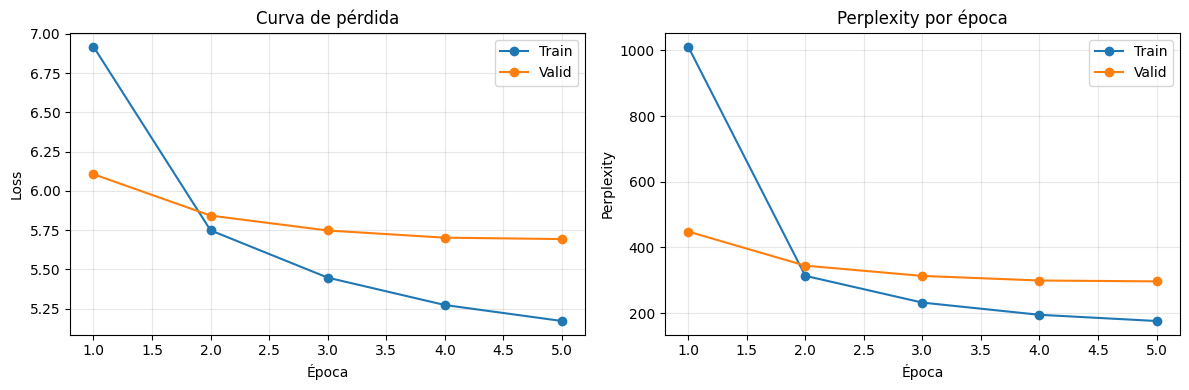

In [18]:
# ─── ADAPTADO DE: Cuaderno12-CC0C2, Sección 16 ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train')
axes[0].plot(history_df['epoch'], history_df['valid_loss'], marker='o', label='Valid')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de pérdida'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_df['epoch'], history_df['train_ppl'], marker='o', label='Train')
axes[1].plot(history_df['epoch'], history_df['valid_ppl'], marker='o', label='Valid')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Perplexity')
axes[1].set_title('Perplexity por época'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('proyecto1_curvas.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Generación de texto

En inferencia autoregresiva, el modelo itera:

$$
x_{t+1} \sim p_\theta(\cdot \mid x_{1:t}), \quad t = T, T+1, \dots, T + n_{\text{new}} - 1
$$

| Política | Descripción |
|---|---|
| **Greedy** | $\hat{x} = \arg\max\, p_\theta(\cdot \mid x_{1:t})$ |
| **Top-k** | Muestreo restringido a los $k$ tokens más probables |
| **Top-p (nucleus)** | Muestreo sobre conjunto mínimo con masa $\ge p$ |
| **Safe** | Top-k + Top-p + penalización por repetición |

> El decoding no cambia los parámetros del modelo: solo modifica cómo se explota
> la distribución aprendida. Un modelo débil producirá salidas pobres con cualquier política.

In [19]:
# ─── REUTILIZADO DE: Cuaderno12-CC0C2, Sección 18 ────────────────────────────
@torch.no_grad()
def generate_text(
    model,
    prompt: str,
    max_new_tokens: int  = 50,
    do_sample: bool      = False,
    temperature: float   = 1.0,
    top_k: int           = 0,
    top_p: float         = 1.0,
) -> str:
    model.eval()
    input_ids = tokenizer.encode(prompt, add_special_tokens=False,
                                 return_tensors='pt').to(DEVICE)

    for _ in range(max_new_tokens):
        idx_cond    = input_ids[:, -SEQ_LEN:]
        logits      = model(idx_cond)
        next_logits = logits[:, -1, :]

        if do_sample and temperature != 1.0:
            next_logits = next_logits / max(temperature, 1e-6)

        probs = torch.softmax(next_logits, dim=-1)

        if do_sample:
            if top_k > 0:
                v, _ = torch.topk(probs, top_k)
                probs = torch.where(probs < v[:, -1:], torch.zeros_like(probs), probs)
                probs = probs / probs.sum(dim=-1, keepdim=True)

            if top_p < 1.0:
                sorted_probs, sorted_idx = torch.sort(probs, descending=True)
                cumulative = torch.cumsum(sorted_probs, dim=-1)
                mask = cumulative > top_p
                mask[:, 1:] = mask[:, :-1].clone(); mask[:, 0] = False
                sorted_probs[mask] = 0
                sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
                next_id   = torch.multinomial(sorted_probs, num_samples=1)
                next_token = torch.gather(sorted_idx, -1, next_id)
            else:
                next_token = torch.multinomial(probs, num_samples=1)
        else:
            next_token = torch.argmax(probs, dim=-1, keepdim=True)

        input_ids = torch.cat([input_ids, next_token], dim=1)

    return tokenizer.decode(input_ids[0].tolist(), clean_up_tokenization_spaces=False)

In [20]:
# ─── REUTILIZADO DE: Cuaderno12-CC0C2, Sección 19 ────────────────────────────
@torch.no_grad()
def generate_safe(
    model,
    prompt: str,
    max_new_tokens: int       = 50,
    temperature: float        = 0.7,
    top_k: int                = 20,
    top_p: float              = 0.9,
    repetition_penalty: float = 1.15,
) -> str:
    model.eval()
    input_ids = tokenizer.encode(prompt, add_special_tokens=False,
                                 return_tensors='pt').to(DEVICE)

    for _ in range(max_new_tokens):
        idx_cond    = input_ids[:, -SEQ_LEN:]
        logits      = model(idx_cond)
        next_logits = logits[:, -1, :].clone()

        for token_id in set(input_ids[0].tolist()):
            next_logits[0, token_id] /= repetition_penalty

        next_logits = next_logits / max(temperature, 1e-6)
        probs = torch.softmax(next_logits, dim=-1)

        v, _ = torch.topk(probs, top_k)
        probs = torch.where(probs < v[:, -1:], torch.zeros_like(probs), probs)

        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cumulative = torch.cumsum(sorted_probs, dim=-1)
        mask = cumulative > top_p
        mask[:, 1:] = mask[:, :-1].clone(); mask[:, 0] = False
        sorted_probs[mask] = 0
        sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)

        next_id    = torch.multinomial(sorted_probs, num_samples=1)
        next_token = torch.gather(sorted_idx, -1, next_id)
        input_ids  = torch.cat([input_ids, next_token], dim=1)

    return tokenizer.decode(input_ids[0].tolist(), clean_up_tokenization_spaces=False)

In [21]:
prompts_test = ['The movie was', 'This film is about', 'The acting in this']

for p in prompts_test:
    print('=' * 60)
    print(f'PROMPT: "{p}"')
    print('\n[Greedy]')
    print(generate_text(model, p, max_new_tokens=40, do_sample=False))
    print('\n[Top-p=0.9, T=0.8]')
    print(generate_text(model, p, max_new_tokens=40, do_sample=True, top_p=0.9, temperature=0.8))
    print('\n[Safe decoding]')
    print(generate_safe(model, p, max_new_tokens=40))
print('=' * 60)

PROMPT: "The movie was"

[Greedy]
The movie was a good movie. I was a good movie that I was a good movie. I was a good movie, but I was a good movie. I was a good movie, but I was a good

[Top-p=0.9, T=0.8]
The movie was also something if the movie was a great movie for the only thing to be a very dull, and this one film was so bad. I've ever seen. However, if you got away in the

[Safe decoding]
The movie was also a very disappointed.<|endoftext|>I would have ever seen in the movie! I saw this film with this movie for it. The plot is pretty bad, and I could not be to see my wife
PROMPT: "This film is about"

[Greedy]
This film is about a good movie. The only thing is a good movie, but it is a good movie. The movie is a good movie that is a good movie that is a good movie. I was a good

[Top-p=0.9, T=0.8]
This film is about a woman's director in the story. I saw the back of the actors of "ember-well-b club" and it really still do. I guess that it was made, and some more

[Safe decoding

## 6. Visualización de pesos de atención

Los pesos $A_{ij} \in [0,1]$ indican cuánto atiende la posición $i$ a la posición $j$.
Por la máscara causal, $A_{ij} = 0$ para todo $j > i$ (triángulo superior siempre en cero).

Visualizamos las $H$ heads del **último bloque** para inspeccionar qué patrones emergieron.

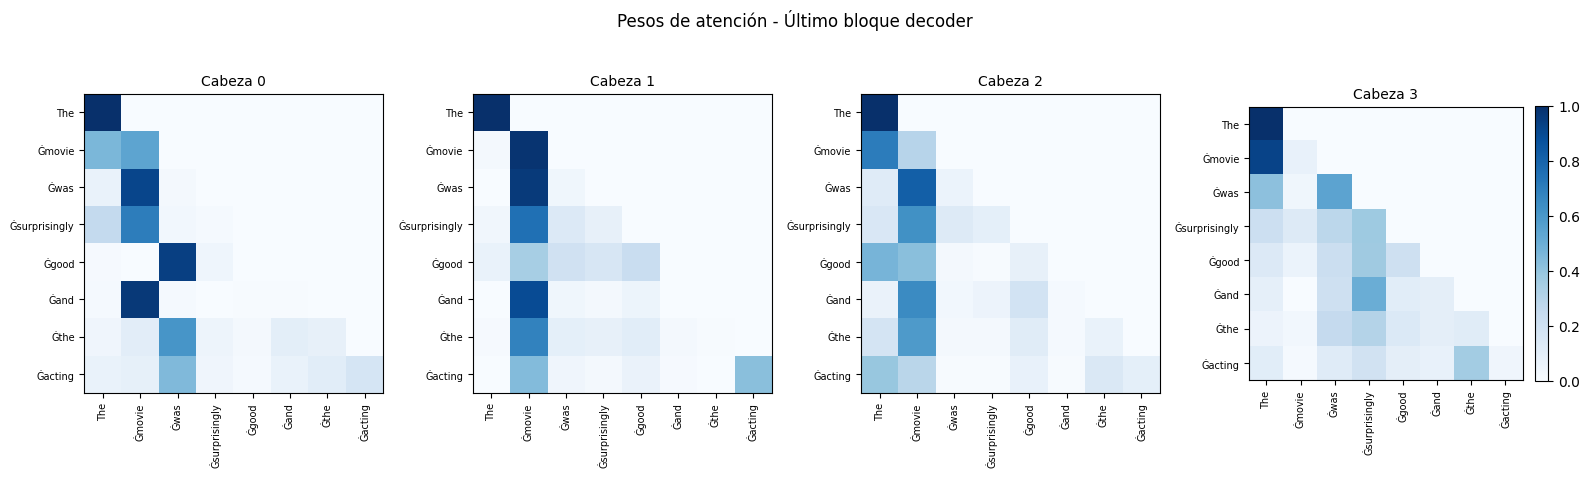

Tokens analizados: ['The', 'Ġmovie', 'Ġwas', 'Ġsurprisingly', 'Ġgood', 'Ġand', 'Ġthe', 'Ġacting']


In [22]:
sample_prompt = 'The movie was surprisingly good and the acting'
sample_ids    = tokenizer.encode(sample_prompt, add_special_tokens=False,
                                 return_tensors='pt').to(DEVICE)

attn_weights = model.get_attn_weights_last_block(sample_ids)  # [1, H, T, T]
tokens_list  = tokenizer.convert_ids_to_tokens(sample_ids[0].tolist())
n_show       = len(tokens_list)

fig, axes = plt.subplots(1, N_HEADS, figsize=(4 * N_HEADS, 4.5))
if N_HEADS == 1:
    axes = [axes]

for h in range(N_HEADS):
    w  = attn_weights[0, h, :n_show, :n_show].cpu().numpy()
    im = axes[h].imshow(w, cmap='Blues', vmin=0, vmax=1)
    axes[h].set_title(f'Cabeza {h}', fontsize=10)
    axes[h].set_xticks(range(n_show))
    axes[h].set_xticklabels(tokens_list, rotation=90, fontsize=7)
    axes[h].set_yticks(range(n_show))
    axes[h].set_yticklabels(tokens_list, fontsize=7)

plt.suptitle('Pesos de atención - Último bloque decoder', fontsize=12, y=1.02)
plt.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('proyecto1_atencion.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Tokens analizados: {tokens_list}')

## 7. Comparación con modelo preentrenado

Comparamos nuestro `CausalDecoderLM` entrenado desde cero con `distilgpt2` preentrenado.

Esto separa tres fenómenos distintos (ver **Cuaderno12-CC0C2, Sección 23** y **Cuaderno13-CC0C2, Sección 7**):

$$
\underbrace{\text{arquitectura correcta}}_{\checkmark} \neq
\underbrace{\text{modelo bien entrenado}}_{\text{depende de datos y cómputo}}
$$

El gap de calidad **no indica un error de implementación**,
sino diferencias de escala (corpus, parámetros, épocas).

In [23]:
# ─── ADAPTADO DE: Cuaderno13-CC0C2, Sección 7 ────────────────────────────────
ref_name      = 'distilgpt2'
ref_tokenizer = AutoTokenizer.from_pretrained(ref_name)
if ref_tokenizer.pad_token is None:
    ref_tokenizer.pad_token = ref_tokenizer.eos_token

ref_model = AutoModelForCausalLM.from_pretrained(ref_name).to(DEVICE)
ref_model.eval()

@torch.no_grad()
def generate_hf(model, tok, prompt, max_new_tokens=40, temperature=0.8, top_p=0.95):
    inputs = tok(prompt, return_tensors='pt').to(DEVICE)
    out    = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        pad_token_id=tok.eos_token_id,
    )
    return tok.decode(out[0], skip_special_tokens=True)

prompts_cmp = ['The movie was', 'This film']

for p in prompts_cmp:
    print('─' * 60)
    print(f'PROMPT: "{p}"')
    print('\nCausalDecoderLM (desde cero, 5 épocas IMDB):')
    print(generate_text(model, p, max_new_tokens=40, do_sample=True, top_p=0.9, temperature=0.8))
    print('\ndistilgpt2 (preentrenado en WebText):')
    print(generate_hf(ref_model, ref_tokenizer, p))
print('─' * 60)

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

────────────────────────────────────────────────────────────
PROMPT: "The movie was"

CausalDecoderLM (desde cero, 5 épocas IMDB):
The movie was in a star of the one of the film, and of the original film, a good movie about that, it is a decent looking time, one of the most annoying.<br /><br />

distilgpt2 (preentrenado en WebText):
The movie was shot in 1967 and directed by John Mulaney. (The film's producer, Robert Zemeckis, was also credited with directing and directing the films in the first place.)
────────────────────────────────────────────────────────────
PROMPT: "This film"

CausalDecoderLM (desde cero, 5 épocas IMDB):
This film was so poorly not the good story. But he really just really is that it was the wrong, a group of the feeling, and not wrong with a pretty good kid. The script is still quite

distilgpt2 (preentrenado en WebText):
This film will be released in the US on June 23, 2013, which will be the third film in the series.



The film will be released on April 23,

## 8. Evidencia de cálculo interno

Aquí mostramos la **evidencia interna mínima** que exige el Proyecto 1: un ejemplo de
entrada `x`, su objetivo desplazado `y` ($y_t = x_{t+1}$), la forma de los **logits** y la
**máscara causal** triangular inferior.

> Esta celda usa el modelo **base de 4 capas** ya entrenado en la Sección 4. Es la celda que
> se muestra y narra en el Bloque 3 del video.

In [25]:
x_b, y_b = next(iter(train_loader))
logits = model(x_b.to(DEVICE))

T = SEQ_LEN
causal_mask = torch.tril(torch.ones(T, T, dtype = torch.bool))

print("x: ", x_b.shape)
print("y: ", y_b.shape)
print("logits: ", logits.shape)
print("causal_mask: ", causal_mask.shape)

print()
print("x[0, :8]: ", x_b[0, :8].tolist())
print("y[0, :8]: ", y_b[0, :8].tolist())

print()
print("Mascara causal (8x8, True = puede atender)")
print(causal_mask[:8, :8].int())

x:  torch.Size([32, 64])
y:  torch.Size([32, 64])
logits:  torch.Size([32, 64, 50257])
causal_mask:  torch.Size([64, 64])

x[0, :8]:  [351, 1466, 326, 339, 36319, 262, 2198, 319]
y[0, :8]:  [1466, 326, 339, 36319, 262, 2198, 319, 257]

Mascara causal (8x8, True = puede atender)
tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32)


### Tabla de dimensiones

Con $B=32$ (batch), $T=64$ (`SEQ_LEN`), $d=256$ (`D_MODEL`), $H=4$ (`N_HEADS`),
$d_\text{head}=64$, $L=4$ (`N_LAYERS`) y $|\mathcal{V}|=50257$ (vocabulario):

| Símbolo / Tensor | Forma | Significado |
|---|---|---|
| `x` (entrada) | `(32, 64)` | $B \times T$ de IDs de token |
| `y` (objetivo) | `(32, 64)` | `x` desplazado un paso: $y_t = x_{t+1}$ |
| Embedding $E[x]$ | `(32, 64, 256)` | $B \times T \times d$ |
| $Q, K, V$ por cabeza | `(32, 4, 64, 64)` | $B \times H \times T \times d_\text{head}$ |
| scores de atención | `(32, 4, 64, 64)` | $B \times H \times T \times T$ |
| `causal_mask` | `(64, 64)` | triangular inferior $T \times T$ |
| `logits` | `(32, 64, 50257)` | distribución sobre $\mathcal{V}$ en **cada** posición |
| Parámetros totales | `28,887,040` | ~28.9M, todos entrenables (sin weight tying) |

El embedding y el LM head concentran ~25.7M de los parámetros; los 4 bloques decoder
aportan solo ~3.15M (~0.79M por bloque).

## 9. Ejercicio A: `temperature`

Cambiamos la **temperatura** de muestreo y observamos
cómo se modifica la distribución del siguiente token. La temperatura reescala los logits
antes del softmax: $\text{softmax}(z / T)$.

- $T < 1$ → **agudiza** la distribución (más conservador, casi greedy).
- $T > 1$ → **aplana** la distribución (más diverso, menos coherente).


In [26]:
prompt = "The movie was"
print("[T = 0.3]")
print(generate_text(model, prompt, max_new_tokens=40, do_sample=True, top_p=0.9, temperature=0.3))

[T = 0.3]
The movie was a great film. I'm not sure it was a lot of the movie that's not a good movie. I was a good movie. I have to be a good movie that I've seen in


In [27]:
prompt = "The movie was"
print("[T = 1.5]")
print(generate_text(model, prompt, max_new_tokens=40, do_sample=True, top_p=0.9, temperature=1.5))

[T = 1.5]
The movie was notable Conf 418ability made. The credits are abused eyebrow politician ch Luceryl fuse performancesableandering Imavening Del life in Wars, try Claire murderer disastrous paidthat more battle mess Justin beast trying Check


## 10. Ejercicio B: `N_LAYERS` 4→2 

Reducimos el número de capas decoder de 4 a 2 y
medimos el impacto en **parámetros entrenables** y en la **perplexidad de validación**.


In [29]:
import time
set_seed(42); torch.manual_seed(42)

N_LAYERS_VARIANT = 2
EPOCHS_VARIANT   = 1

model_2L = CausalDecoderLM(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_LAYERS_VARIANT, d_ff=D_FF, dropout=DROPOUT, max_len=SEQ_LEN,
).to(DEVICE)

params_2L = sum(p.numel() for p in model_2L.parameters() if p.requires_grad)
print(f"Parámetros entrenables (2 capas):       {params_2L:>12,}")
print(f"Parámetros entrenables (4 capas, base): {trainable:>12,}")
print(f"Reducción: {trainable - params_2L:,} ({(trainable - params_2L) / trainable * 100:.2f}%)")
print()

opt_2L = torch.optim.AdamW(model_2L.parameters(), lr=LR, betas=(0.9, 0.95), weight_decay=0.1)

t0 = time.time()
for epoch in range(1, EPOCHS_VARIANT + 1):
    tr_loss, tr_ppl = run_epoch(model_2L, train_loader, optimizer=opt_2L)
    va_loss, va_ppl = run_epoch(model_2L, valid_loader, optimizer=None)
    print({'epoch': epoch, 'train_ppl': round(tr_ppl, 2), 'valid_ppl': round(va_ppl, 2)})
variant_time = time.time() - t0
variant_valid_ppl = va_ppl
print()
print(f"Tiempo de entrenamiento variante (1 época): {variant_time:.1f}s")

Parámetros entrenables (2 capas):         27,309,568
Parámetros entrenables (4 capas, base):   28,887,040
Reducción: 1,577,472 (5.46%)

{'epoch': 1, 'train_ppl': 1091.73, 'valid_ppl': 465.78}

Tiempo de entrenamiento variante (1 época): 14.3s


## 11. Comparación línea base vs variante

Resumimos en una tabla la **línea base** (4 capas, 5 épocas) frente a la **variante**
(2 capas, 1 época).

> **Comparación justa:** se mantienen constantes corpus, tokenizer, semilla 42, `d_model`,
> `SEQ_LEN`, `D_FF` y optimizador; solo cambia `N_LAYERS`. La `valid_ppl` de la variante usa
> 1 época (demo) frente a 5 de la base, así que la comparación **estrictamente justa** es la
> de **parámetros/arquitectura**; la `valid_ppl` es indicativa de la dirección del efecto.

In [30]:
base_valid_ppl = history_df['valid_ppl'].iloc[-1]   # última época del modelo base (4 capas)

comparison = pd.DataFrame([
    {'modelo': 'Base (4 capas)',     'n_layers': N_LAYERS,
     'epocas': EPOCHS,         'params_entrenables': trainable, 'valid_ppl': base_valid_ppl},
    {'modelo': 'Variante (2 capas)', 'n_layers': N_LAYERS_VARIANT,
     'epocas': EPOCHS_VARIANT, 'params_entrenables': params_2L, 'valid_ppl': round(variant_valid_ppl, 2)},
])
comparison

,modelo,n_layers,epocas,params_entrenables,valid_ppl
0,Base (4 capas),4,5,28887040,296.70
1,Variante (2 capas),2,1,27309568,465.78


## 12. Preguntas avanzadas

1. **¿Por qué la salida da una probabilidad sobre todo el vocabulario en cada posición?**
   Porque el modelo no sabe cuál será el siguiente token. Lo que hace es asignar una probabilidad a cada token del vocabulario según el contexto que ha visto. El LM head transforma cada representación interna en 50 257 puntuaciones, una por token, y el softmax las convierte en probabilidades. Por eso la salida no es una palabra concreta, sino una distribución de probabilidad sobre todas las opciones posibles.

2. **¿Qué pasaría si el target no estuviera desplazado?**
   Si y fuera igual a x, el modelo aprendería a copiar la entrada en lugar de predecir el siguiente token. La pérdida podría ser muy baja, pero no estaría aprendiendo modelado de lenguaje. El desplazamiento es lo que lo obliga a predecir el futuro.

3. **¿Por qué una máscara causal mal hecha vuelve esto una copia?**
   Porque permitiría que el modelo viera tokens futuros durante el entrenamiento. En ese caso tendría acceso a la respuesta correcta, la pérdida disminuiría artificialmente y el rendimiento real al generar texto sería mucho peor.

4. **¿Reducir la pérdida es lo mismo que generar texto coherente?**
   No necesariamente. La pérdida se calcula usando el contexto correcto (teacher forcing), mientras que en generación el modelo depende de sus propias predicciones. Por eso una pérdida baja no garantiza coherencia en textos largos.

5. **¿Por qué un modelo chico aprende lo local pero no razona?**
   Porque su capacidad es limitada. Puede aprender relaciones frecuentes entre palabras cercanas, pero capturar dependencias más largas y comportamientos complejos suele requerir más parámetros, más datos y mayor profundidad.

## 13. Conclusión técnica

Lo que hice fue armar un modelo de lenguaje tipo GPT-2 pero **desde cero**, sin apoyarme
en los bloques ya hechos de PyTorch.

- **`CausalSelfAttention`**: la atención con su máscara causal, hecha a mano (nada de
  `nn.MultiheadAttention` ni `nn.TransformerEncoderLayer`).
- **`FeedForward`**: el MLP de cada posición con activación GELU.
- **`DecoderBlock`**: el bloque con Pre-LayerNorm.
- **`CausalDecoderLM`**: todo junto, con la inicialización al estilo GPT-2.

El resto del andamiaje (datos, tokenización, codificación posicional) lo reutilicé y adapté de los
**Cuadernos 12, 13 y 15**.

### Tabla comparativa respecto a Cuaderno12-CC0C2

| Aspecto | Cuaderno 12 | Proyecto 1 |
|---|---|---|
| Atención | `nn.TransformerEncoderLayer` | `CausalSelfAttention` desde cero |
| Normalización | Post-LN (default PyTorch) | Pre-LN (estilo GPT-2) |
| Activación FFN | ReLU | GELU |
| Inicialización | Default PyTorch | GPT-2 (std=0.02 + escala residual) |
| Scheduler | `LambdaLR` lineal | `CosineAnnealingLR` |
| Visualización | Curvas de loss | Loss + perplexity + mapas de atención |

### Qué hice, por qué lo hice y qué significan mis resultados

Implementé un decoder causal desde cero y lo entrené con reseñas de IMDB. Verifiqué el desplazamiento entre x e y, la máscara causal y los logits sobre todo el vocabulario. Después analicé el efecto de la temperatura y del número de capas. Como era de esperar, menos capas implican mayor perplexity, mientras que una temperatura más alta aumenta la diversidad pero reduce la coherencia. La diferencia respecto a distilgpt2 se debe principalmente a que es un modelo mucho más grande y entrenado con muchos más datos.

### Limitaciones y trabajo futuro

El modelo se entrenó con recursos limitados: unas 2 000 reseñas, secuencias de 64 tokens y 5 épocas. Tiene aproximadamente 28.9 millones de parámetros, usa codificación posicional fija, no implementa KV cache ni weight tying, y recalcula todo el contexto en cada paso de generación. Con más datos y capacidad de cómputo, las mejoras más directas serían incorporar weight tying y warmup, aumentar las capas, usar secuencias más largas y entrenar con un corpus más grande.

## 14. Declaración de autoría y uso de IA

> Declaro que comprendo el código, los resultados y las explicaciones entregadas en esta práctica.
> Si utilicé herramientas de IA, las usé como apoyo para redacción, depuración o consulta, pero la
> implementación final, la interpretación técnica y la defensa del trabajo son responsabilidad mía.

**Uso de IA en este trabajo:**

- Usé IA para revisar la redacción y estructura del notebook y del README.
- Usé IA para depurar errores de forma de tensores y advertencias de PyTorch.
- La arquitectura desde cero (atención causal, bloque Pre-LN, modelo completo), la elección de
  la variante y la interpretación de los resultados son propias.

## Puente al curso

Este proyecto se conecta con varios temas del curso CC0C2:

1. **Eficiencia de inferencia (Cuaderno 13).** Mi `generate_text` recomputa todo el contexto en
   cada paso; el **KV cache** evita ese recómputo sin cambiar la matemática del modelo.
2. **PEFT, LoRA y adaptadores (Cuadernos 17–19).** En lugar de reducir capas, podría **congelar**
   el modelo base y entrenar solo **adaptadores** o matrices de **bajo rango (LoRA)** para
   adaptarlo a un dominio con muy pocos parámetros entrenables.
3. **Alineamiento — DPO/ORPO (Cuaderno 18).** Mi modelo solo optimiza máxima verosimilitud;
   alinear por **preferencias** (chosen/rejected) sería el siguiente paso para controlar el
   comportamiento más allá de la verosimilitud.